## Objetivo da Análise

Esta análise busca responder:
“Quais fatores influenciam o preço e a demanda dos anúncios do Airbnb no Rio de Janeiro?”

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [3]:
import pandas as pd

df = pd.read_csv("listings.csv")

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,821198084644106078,https://www.airbnb.com/rooms/821198084644106078,20250926170004,2025-09-27,city scrape,Bright and Peaceful Leblon Loft,Welcome! Come relax in our bright and stylish ...,Beautiful tree lined street just 3 blocks from...,https://a0.muscache.com/pictures/hosting/Hosti...,84350716,...,4.94,4.99,4.85,NaN,f,1,1,0,0,2.72
1,821198370698658112,https://www.airbnb.com/rooms/821198370698658112,20250926170004,2025-09-27,city scrape,Copacabana 100% reformado.,Guarantee of a safe and quality stay! <br /><...,"Copacabana, in the part near the neighborhood ...",https://a0.muscache.com/pictures/miso/Hosting-...,4347269,...,NaN,NaN,NaN,NaN,f,2,2,0,0,NaN
2,821200521820144734,https://www.airbnb.com/rooms/821200521820144734,20250926170004,2025-09-26,city scrape,hambiente familia,Relax with the whole family in this quiet acco...,NaN,https://a0.muscache.com/pictures/7485ea61-a28a...,499903412,...,NaN,NaN,NaN,NaN,t,2,1,1,0,NaN
3,821213014263313420,https://www.airbnb.com/rooms/821213014263313420,20250926170004,2025-09-27,previous scrape,Amazing en suite bedroom Leblon,"Kick back and relax in this calm, stylish spac...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,449763717,...,5.00,5.00,4.67,NaN,f,2,1,1,0,0.10
4,821223043903573522,https://www.airbnb.com/rooms/821223043903573522,20250926170004,2025-09-27,city scrape,Incrível apartamento frente mar,Amazing 1-bedroom apartment facing the sea. Co...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,25961210,...,5.00,5.00,5.00,NaN,f,1,1,0,0,0.60


In [4]:
cidade = "Rio de Janeiro"
print(f"Cidade analisada: {cidade}")

Cidade analisada: Rio de Janeiro


In [5]:
#colunas, linhas
df.shape

(43068, 79)

In [6]:
pd.set_option('display.max_rows', None)
#colunas
#list(df.columns)#Tipo de dado de cada coluna
df.dtypes

id                                                int64
listing_url                                         str
scrape_id                                         int64
last_scraped                                        str
source                                              str
name                                                str
description                                         str
neighborhood_overview                               str
picture_url                                         str
host_id                                           int64
host_url                                            str
host_name                                           str
host_since                                          str
host_location                                       str
host_about                                          str
host_response_time                                  str
host_response_rate                                  str
host_acceptance_rate                            

In [7]:
#Ranking dos que possuem mais valores nulos
df.isnull().sum().sort_values(ascending=False)

license                                         43068
calendar_updated                                43068
neighbourhood_group_cleansed                    43068
neighbourhood                                   26738
neighborhood_overview                           26738
host_about                                      22464
review_scores_value                              9188
review_scores_location                           9187
review_scores_communication                      9187
review_scores_accuracy                           9187
review_scores_checkin                            9187
last_review                                      9186
reviews_per_month                                9186
review_scores_rating                             9186
review_scores_cleanliness                        9186
first_review                                     9186
host_location                                    8873
host_response_time                               7178
host_response_rate          

In [8]:
colunas_relevantes = [
    'price',
    'room_type', 
    'neighbourhood_cleansed',
    'accommodates',
    'number_of_reviews', 
    'reviews_per_month',  
    'amenities'                   
]

In [9]:
df[colunas_relevantes].info()

<class 'pandas.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   price                   38670 non-null  str    
 1   room_type               43068 non-null  str    
 2   neighbourhood_cleansed  43068 non-null  str    
 3   accommodates            43068 non-null  int64  
 4   number_of_reviews       43068 non-null  int64  
 5   reviews_per_month       33882 non-null  float64
 6   amenities               43068 non-null  str    
dtypes: float64(1), int64(2), str(4)
memory usage: 2.3 MB


### Tratamento de PRICE
**Justificativa de Price:** Realizei o tratamento dos dados na coluna PRICE, que possuia caracteres especiais. Os removi e converti a coluna em float para melhorar a ánalise com base nos preços

In [10]:
df['price'].head(10)

0      $580.00
1    $1,900.00
2      $700.00
3          NaN
4      $500.00
5      $461.00
6          NaN
7      $281.00
8      $950.00
9      $450.00
Name: price, dtype: str

In [11]:
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

In [12]:
df['price'].head(10)

0     580.0
1    1900.0
2     700.0
3       NaN
4     500.0
5     461.0
6       NaN
7     281.0
8     950.0
9     450.0
Name: price, dtype: float64

In [13]:
df[colunas_relevantes].head(5)

,price,room_type,neighbourhood_cleansed,accommodates,number_of_reviews,reviews_per_month,amenities
0,580.0,Entire home/apt,Leblon,4,86,2.72,"[""Hangers"", ""Hot water kettle"", ""Wine glasses""..."
1,1900.0,Entire home/apt,Copacabana,2,0,NaN,"[""Smoking allowed"", ""TV"", ""Kitchen"", ""Washer"",..."
2,700.0,Entire home/apt,Pavuna,4,0,NaN,"[""BBQ grill"", ""Exterior security cameras on pr..."
3,NaN,Private room,Leblon,2,3,0.10,"[""Essentials"", ""Hair dryer"", ""Cooking basics"",..."
4,500.0,Entire home/apt,Barra da Tijuca,4,11,0.60,"[""Outdoor shower"", ""Pool"", ""Free parking on pr..."


In [14]:
df['price'].isnull().sum()

np.int64(4398)

In [15]:
df = df.dropna(subset=['price']).copy()

In [16]:
df['price'].isnull().sum()

np.int64(0)

### Transformação de amenities
**Justificativa das amenities:** Optei por extrair as 5 amenities mais frequentes na base de dados pois elas representam a infraestrutura básica e o padrão mínimo esperado pela maioria dos hóspedes

In [17]:
# 1. Removemos os colchetes e aspas da string usando regex
amenities_limpas = df['amenities'].str.replace(r'[\[\]"]', '', regex=True)

# 2. Separamos o texto por vírgulas para criar uma lista
amenities_listas = amenities_limpas.str.split(', ')

# 3.separa cada item da lista em uma linha temporária.
ranking_amenities = amenities_listas.explode().value_counts()

# Mostrando amenities que mais aparecem no Rio de Janeiro
display(ranking_amenities.head(5))

amenities
Kitchen                  35206
Wifi                     34973
Hot water                25261
Dishes and silverware    24148
Air conditioning         24106
Name: count, dtype: int64

In [48]:
top_amenities = ranking_amenities.head(5).index.tolist()

import re
colunas_novas = []

for amenidade in top_amenities:
    nome_limpo = re.sub(r'[^a-zA-Z0-9]', '_', amenidade.lower())
    nome_coluna = f'has_{nome_limpo}'
    
    df[nome_coluna] = df['amenities'].str.contains(amenidade, case=False, na=False).astype(int)
    
    colunas_novas.append(nome_coluna)

df[['price', 'accommodates'] + colunas_novas].head(10)    

,price,accommodates,has_kitchen,has_wifi,has_hot_water,has_dishes_and_silverware,has_air_conditioning
0,580.0,4,1,1,1,1,0
1,1900.0,2,1,1,0,0,1
2,700.0,4,1,0,0,0,1
4,500.0,4,1,1,0,0,1
5,461.0,6,1,1,1,1,1
7,281.0,2,1,1,1,1,0
8,950.0,2,1,1,1,1,1
9,450.0,4,0,1,1,0,0
10,1000.0,6,1,1,1,1,1
11,980.0,3,1,1,1,1,1


In [19]:
resumo = df.groupby('room_type').agg({
    'price': ['mean', 'median'],
    'number_of_reviews': 'mean',
    'accommodates': 'mean'
})
print(resumo)

                      price        number_of_reviews accommodates
                       mean median              mean         mean
room_type                                                        
Entire home/apt  800.152831  350.0         29.843272     4.342234
Hotel room       619.800000  470.0         56.400000     2.933333
Private room     375.078981  205.0         17.672709     2.327003
Shared room      199.075949  105.0          9.377215     4.708861


In [20]:
df.groupby('neighbourhood_cleansed')['price'].mean().sort_values(ascending=False).head(5)

neighbourhood_cleansed
Estácio        7003.148649
Joá            6878.132075
São Conrado    3000.919162
Anchieta       2531.000000
Itanhangá      2528.747191
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

Text(0.5, 1.0, 'Distribuição de Preços')

Text(0.5, 0, 'Preço (R$)')

<Axes: ylabel='room_type'>

Text(0.5, 1.0, 'Preço Mediano por Tipo de Quarto')

Text(0.5, 0, 'Preço Mediano (R$)')

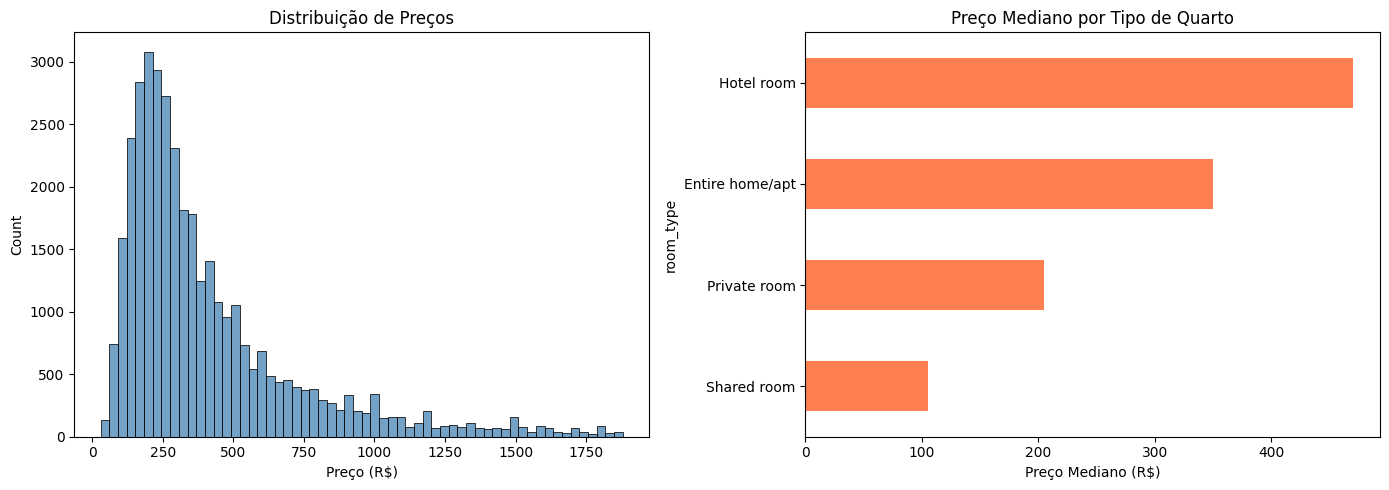

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribuição de preços
df_sem_outlier = df[df['price'] < df['price'].quantile(0.95)]
sns.histplot(df_sem_outlier['price'], bins=60, ax=axes1[0], color='steelblue')
axes1[0].set_title('Distribuição de Preços')
axes1[0].set_xlabel('Preço (R$)')

# 2. Preço médio por tipo de quarto
medias = df.groupby('room_type')['price'].median().sort_values()
medias.plot(kind='barh', ax=axes1[1], color='coral')
axes1[1].set_title('Preço Mediano por Tipo de Quarto')
axes1[1].set_xlabel('Preço Mediano (R$)')

plt.tight_layout()
plt.show() 

<Axes: xlabel='neighbourhood_cleansed'>

Text(0.5, 1.0, 'Top 5 — Média (com outliers)')

<Axes: xlabel='neighbourhood_cleansed'>

Text(0.5, 1.0, 'Top 5 — Mediana')

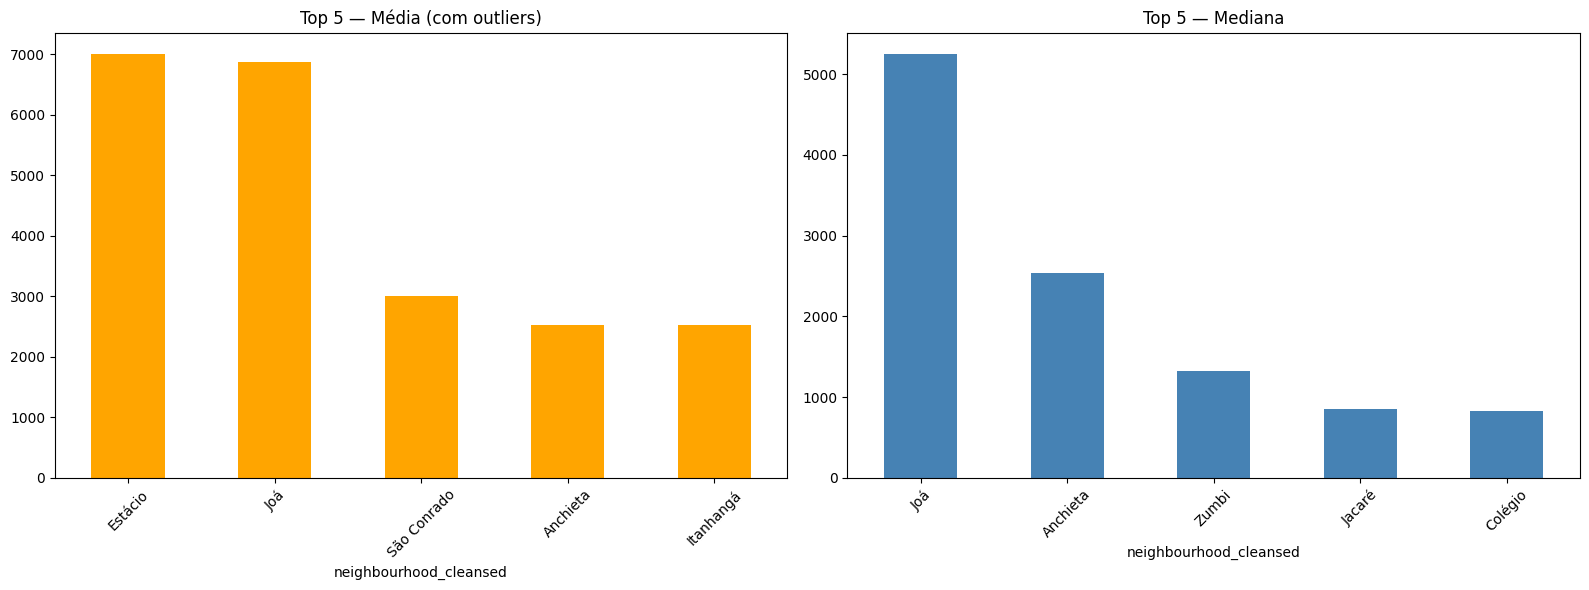

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Média
top_mean = df.groupby('neighbourhood_cleansed')['price'].mean().nlargest(5)
top_mean.plot(kind='bar', ax=axes[0], color='orange')
axes[0].set_title('Top 5 — Média (com outliers)')
axes[0].tick_params(axis='x', rotation=45)

# Mediana
top_median = df.groupby('neighbourhood_cleansed')['price'].median().nlargest(5)
top_median.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Top 5 — Mediana')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [23]:
df_estacio = df[df['neighbourhood_cleansed'] == 'Estácio']

media_estacio = df_estacio['price'].mean()
mediana_estacio = df_estacio['price'].median()

moda_estacio = df_estacio['price'].mode()[0] 

print(f"--- Valores de Preço no Bairro Estácio ---")
print(f"Média (Average): R$ {media_estacio:.2f}")
print(f"Mediana (Valor do meio): R$ {mediana_estacio:.2f}")
print(f"Moda (Preço mais comum): R$ {moda_estacio:.2f}")

anuncios_caros = df_estacio.sort_values(by='price', ascending=False)

display(anuncios_caros[['id', 'name', 'room_type', 'price']].head(5))

--- Valores de Preço no Bairro Estácio ---
Média (Average): R$ 7003.15
Mediana (Valor do meio): R$ 160.00
Moda (Preço mais comum): R$ 160.00


,id,name,room_type,price
7624,30033272,Apartamento em Rio de Janeiro,Entire home/apt,500000.0
23551,1071216377896851973,"Apt arejado, sol da manhã",Private room,1485.0
33742,1338558066930251191,Em frente ao metrô,Entire home/apt,972.0
37042,1389833350160373079,Hospedagem Santo Antônio,Private room,900.0
35733,1363181864923328390,quarto para casal,Private room,765.0


<Axes: xlabel='price', ylabel='number_of_reviews'>

(0.0, 5000.0)

Text(0.5, 1.0, 'Preço vs Demanda (até R$5000)')

<Axes: xlabel='price', ylabel='number_of_reviews'>

(0.0, 1000.0)

Text(0.5, 1.0, 'Preço vs Demanda (até R$1000)')

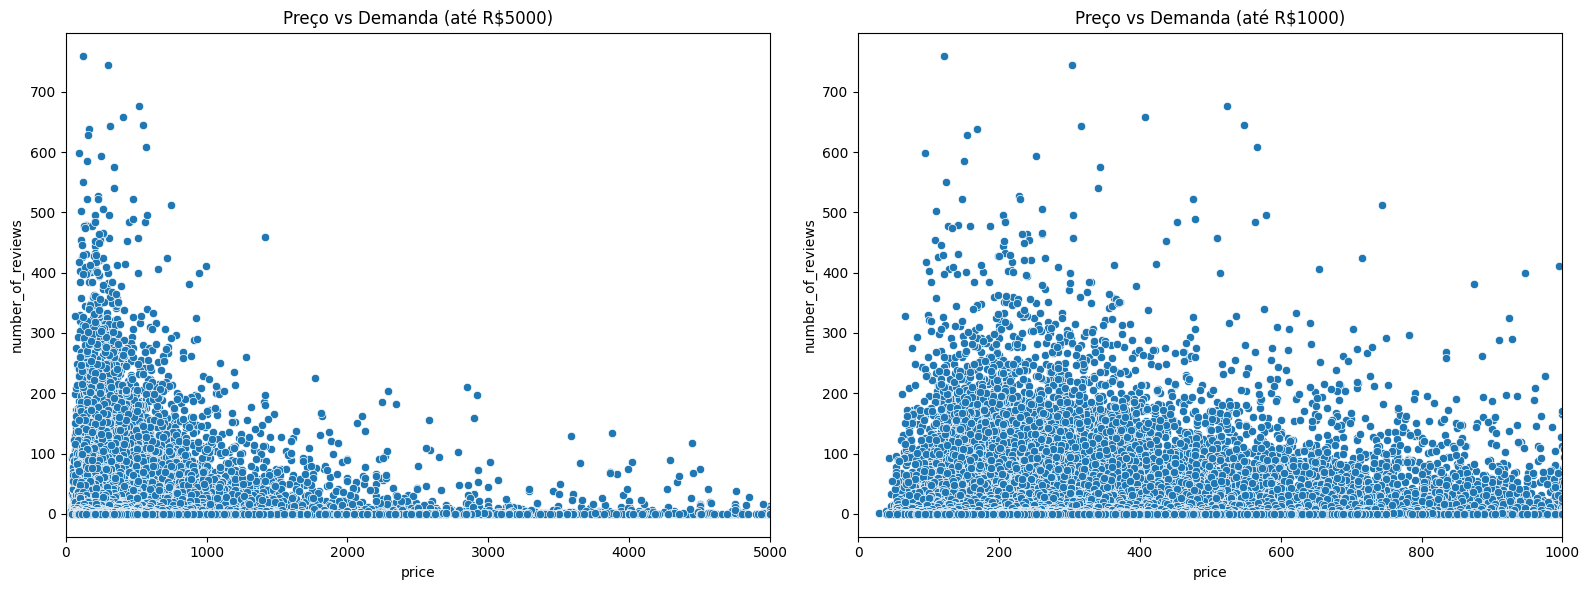

In [24]:
#Proxy de demanda = number_of_reviews
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x='price', y='number_of_reviews', ax=axes[0])
axes[0].set_xlim(0, 5000)
axes[0].set_title('Preço vs Demanda (até R$5000)')

sns.scatterplot(data=df, x='price', y='number_of_reviews', ax=axes[1])
axes[1].set_xlim(0, 1000)
axes[1].set_title('Preço vs Demanda (até R$1000)')

plt.tight_layout()
plt.show()

### Gráfico 1 - Distribuição de preços: 
A distribuição de preços é assimétrica à direita, com a maioria dos anúncios concentrada entre R$100 e R$500. O pico está  em torno de R$200-R$300, indicando que esse é o preço mais comum no mercado. A cauda longa à direita mostra a existência de imóveis de luxo que elevam a média, justificando o uso da mediana como medida mais representativa. (Caso utilize a média, a conta seria altamente influneciada)

### Gráfico 2 — Preço Mediano por Tipo de Quarto:
Hotel room apresenta o maior preço mediano (~R$450), seguido de Entire home/apt (R$350). Private room (R$200) e Shared room (R$100) são significativamente mais baratos. Isso reflete a lógica do mercado: acomodações completas e com serviços agregados comandam preços maiores, enquanto quartos compartilhados atendem um público mais sensível ao preço.

### Gráfico 3 — Top 5 Bairros por Preço Médio:
A média indica Estácio e Joá como os bairros mais caros, porém há distorção nos dados. No caso do Estácio, um valor extremamente alto (outlier) eleva artificialmente a média, não representando a realidade do bairro.

### Gráfico 3.1 — Top 5 Bairros por Preço mediano:
A mediana elimina o impacto de outliers e mostra valores mais realistas. Assim, os bairros apresentados refletem melhor o preço típico das diárias.

### Gráfico 4 - Demanda de procura
A quantidade de demanda está diretamente relacionada ao preço das diárias, a busca por diárias em valores mais acessíveis (R$150 -R$ 450) é muito maior do que para valores mais elevados

In [ ]:
# --- Teste: amenities vs Preço ---

df['qtd_amenities'] = df[colunas_novas].sum(axis=1)
baixa = df[df['qtd_amenities'] <= 2]['price']
alta = df[df['qtd_amenities'] > 2]['price']

from scipy import stats

# H0: preço é igual independentemente da quantidade de amenities
# H1: imóveis com mais amenities são mais caros

stat, p = stats.mannwhitneyu(alta, baixa, alternative='greater')

print("--- Teste: amenities vs Preço ---")
print("amenities consideradas:", colunas_novas)
print(f"p-valor: {p:.4f}")

if p < 0.05:
    print("Conclusão: Imóveis com mais amenities são significativamente mais caros.")
else:
    print("Conclusão: Não há diferença estatística no preço.")

--- Teste: amenities vs Preço ---
amenities consideradas: ['has_kitchen', 'has_wifi', 'has_hot_water', 'has_dishes_and_silverware', 'has_air_conditioning', 'has_tv', 'has_bed_linens', 'has_iron', 'has_hangers', 'has_cooking_basics', 'has_microwave', 'has_essentials', 'has_elevator', 'has_refrigerator', 'has_dedicated_workspace', 'has_hair_dryer', 'has_room_darkening_shades', 'has_washer', 'has_dining_table', 'has_self_check_in']
p-valor: 0.0000
Conclusão: Imóveis com mais amenities são significativamente mais caros.


In [26]:
# --- Teste 2: Bairros têm preços diferentes? ---
# H0: preço médio é igual entre os bairros
# H1: pelo menos um bairro tem preço diferente

# Agrupando apenas bairros com um volume bom de anúncios (mais de 30)
grupos_bairros = [g['price'].values for _, g in df.groupby('neighbourhood_cleansed') if len(g) >= 30]

# Calculando a estatística
stat, p = stats.kruskal(*grupos_bairros)

print(f"\n--- Teste 2: Impacto da Localização no Preço ---")
print(f"p-valor: {p:.4f}")

if p < 0.05:
    print("Conclusão: O bairro afeta fortemente o valor da diária!")
    print("Existe uma diferença de preços real e estatisticamente comprovada entre as diferentes regiões.")
else:
    print("Conclusão: NÃO existe diferença de preço comprovada entre os bairros.")
    print("Estatisticamente, os anfitriões cobram valores parecidos independente da região analisada.")


--- Teste 2: Impacto da Localização no Preço ---
p-valor: 0.0000
Conclusão: O bairro afeta fortemente o valor da diária!
Existe uma diferença de preços real e estatisticamente comprovada entre as diferentes regiões.


In [27]:
from scipy import stats

# --- Teste 3: Superhost vs Demanda ---
# H0: número de reviews é igual entre superhosts e comuns
# H1: superhosts têm mais reviews (maior demanda)

superhosts = df[df['host_is_superhost'] == 't']['number_of_reviews']
comuns = df[df['host_is_superhost'] == 'f']['number_of_reviews']

stat, p = stats.mannwhitneyu(superhosts, comuns, alternative='greater')

print("--- Teste 3: Superhost vs Demanda ---")
print(f"p-valor: {p:.4f}")

if p < 0.05:
    print("Conclusão: Superhosts têm significativamente mais avaliações.")
    print("Isso indica maior demanda para esses anúncios.")
else:
    print("Conclusão: Não há diferença estatisticamente significativa.")

--- Teste 3: Superhost vs Demanda ---
p-valor: 0.0000
Conclusão: Superhosts têm significativamente mais avaliações.
Isso indica maior demanda para esses anúncios.


In [28]:
# --- Diferença entre superhost e comuns ---
agg_dict = {
    'id': 'count',
    'price': 'median',
    'number_of_reviews': 'mean'
}
for col in colunas_novas:
    agg_dict[col] = 'mean'
resumo_host = df.groupby('host_is_superhost').agg(agg_dict)
resumo_host = resumo_host.rename(columns={
    'id': 'total_anuncios',
    'price': 'preco_mediano',
    'number_of_reviews': 'reviews_medio'
})
for col in colunas_novas:
    resumo_host = resumo_host.rename(columns={col: f'perc_{col.replace("has_", "")}'})
colunas_perc = [col for col in resumo_host.columns if col.startswith('perc_')]
resumo_host[colunas_perc] = (resumo_host[colunas_perc] * 100).round(1)
resumo_host['preco_mediano'] = resumo_host['preco_mediano'].round(2)
resumo_host['reviews_medio'] = resumo_host['reviews_medio'].round(1)

display(resumo_host)

,total_anuncios,preco_mediano,reviews_medio,perc_kitchen,perc_wifi,perc_hot_water,perc_dishes_and_silverware,perc_air_conditioning,perc_tv,perc_bed_linens,perc_iron,perc_hangers,perc_cooking_basics
host_is_superhost,,,,,,,,,,,,,
f,23710,349.0,14.1,90.8,94.5,55.4,51.6,66.4,88.1,49.8,49.8,48.6,46.3
t,13673,283.0,49.6,92.5,98.8,83.4,80.3,58.3,92.7,79.0,74.8,75.4,74.0


## Conclusão

A análise dos dados do Airbnb no Rio de Janeiro indica que o preço das diárias é influenciado principalmente pelo tipo de acomodação, localização e quantidade de amenities.Bairros mais valorizados apresentam preços mais elevados.

Em relação à demanda, observou-se que anúncios com preços mais acessíveis concentram maior número de avaliações, sugerindo maior procura. Além disso, anfitriões superhost tendem a apresentar maior demanda, indicando maior atratividade ou qualidade percebida.

Os testes estatísticos confirmaram que:
- A quantidade de amenities influencia o preço dos anúncios;
- O bairro impacta significativamente o valor das diárias;
- Superhosts possuem maior número de avaliações, indicando maior demanda.

Como limitação, destaca-se a presença de outliers nos preços e o uso do número de avaliações como proxy de demanda, que não representa perfeitamente o número real de reservas.